# Demonstration of the functionality of the christoffel module

We demonstrate the functionality of the Christoffel module by using the elastic tensor of forsterite olivine at room conditions.

In [1]:
# TO REMOVE
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

# Make the pyrockwave package importable from the notebooks/ folder
sys.path.insert(0, os.path.join("..", "src"))

In [2]:
# PyRockWave imports
from pyrockwave.christoffel import phase_seismic_properties, full_seismic_properties
from pyrockwave.utils.coordinates import equispaced_S2_grid, sph2cart, cart2sph
import pyrockwave.utils.tensor_tools as tt

The christoffel module has two main functions: ``phase_seismic_properties`` and ``full_seismic_properties``. The former compute phase velocities (Vp, Vs1, Vs2), Vp/Vs ratios and shear-wave splitting for an array of propagation directions while the latter compute phase and group velocities along with other parameters such as enhancement factors and power flow angles. We will explain the meaning of these terms later. We will also explain when you need to calculate phase or group velocities.

## Input data

The data required to estimate the seismic properties in any arbitrary direction of a given material using the Christoffel equation are the density and the stiffness tensor of the material.

The stiffness tensor $C_{ijkl}$ is a fundamental material property that generalises Hooke's law in three dimensions by relating strains to stresses within the elastic regime. This is usually abbreviated to a 6x6 matrix ($C_{ij}$) using Voigt notation with values given in $GPa$. The density is typically expressed in *gcm-3*.

In [3]:
# set the elastic tensor and density of forsterite
Cij = np.array([[296.0,  38.4,  58.2,   0. ,   0. ,   0. ],
                [ 38.4, 179.7,  75.0,   0. ,   0. ,   0. ],
                [ 58.2,  75.0, 210.0,   0. ,   0. ,   0. ],
                [  0. ,   0. ,   0. ,  56.4,   0. ,   0. ],
                [  0. ,   0. ,   0. ,   0. ,  71.0,   0. ],
                [  0. ,   0. ,   0. ,   0. ,   0. ,  71.0]])

density_gcm3 = 3.275

The seismic properties of most materials are anisotropic, i.e. they depend on direction. Consequently, we also need to provide as input the propagation directions of interest, typically , denoted as wave vectors or $\vec{q}$. To observe anisotropy in 3D, we need to estimate the properties along at least three perpendicular directions, or more typically along a set of equispaced spherical grid directions. Wavevectors can be defined in spherical coordinates (polar and azimuthal angles) or in Cartesian coordinates ($x, y, z$) normalised to the unit sphere (i.e. vectors of size 1 or unit vectors).The submodule ``utils.coordinates`` contains several functions to generate an equispaced spherical grid of wavevectors, and to convert between spherical and Cartesian coordinates, and vice versa.

In this case, we proceed as follows:

- Create a set of equispaced wavevectors in spherical coordinates.
- Convert from spherical to 3D Cartesian unit vectors (for plotting).

In [4]:
# create a set of equispaced wavevectors in spherical coordinates using radians
azimuth_ang, polar_ang = equispaced_S2_grid(num_points=9289, degrees=False)

# convert from spherical to 3d cartesian
x, y, z = sph2cart(azimuth_rad=azimuth_ang, polar_rad=polar_ang)

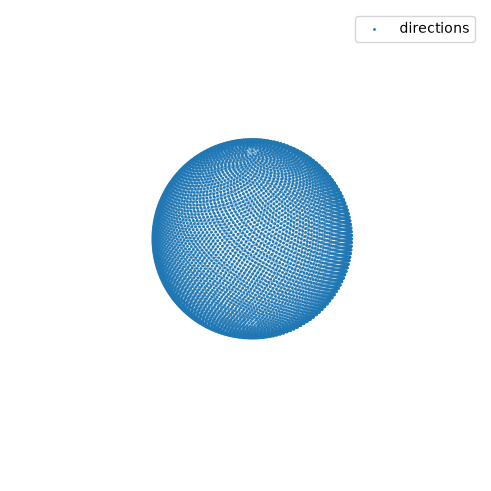

In [5]:
# plot to test
fig1, ax = plt.subplots(subplot_kw={"projection": "3d"}, constrained_layout=True)

ax.scatter(x, y, z, s=1, label="directions")

ax.axis("off")
ax.axis("equal")
ax.legend()

## Compute phase velocities

TODO

In [6]:
velocities, _ = phase_seismic_properties(
    Cij=Cij,
    density_gcm3=density_gcm3,
    azimuths_deg=np.rad2deg(azimuth_ang),
    polar_deg=np.rad2deg(polar_ang),
)


In [7]:
velocities

,azimuths_deg,polar_deg,qx,qy,qz,Vs2_phase_kms,Vs1_phase_kms,Vp_phase_kms,VpVs1,VpVs2,SWS_perc,dVs2_perc,dVs1_perc,dVp_perc
0,0.000000,0.000000,0.000000e+00,0.000000,1.000000,4.149864,4.656113,8.007630,1.719810,1.929612,11.497844,-11.344288,-0.529032,0.354407
1,0.000000,3.757067,6.552620e-02,0.000000,0.997851,4.152170,4.670805,8.006114,1.714076,1.928176,11.756463,-11.295032,-0.215164,0.335406
2,222.492236,3.940516,-5.067255e-02,-0.046420,0.997636,4.152105,4.664918,8.005024,1.716005,1.927944,11.632331,-11.296420,-0.340937,0.321746
3,84.984472,4.115808,6.274775e-03,0.071498,0.997421,4.151926,4.656249,8.003604,1.718895,1.927685,11.451248,-11.300252,-0.526138,0.303953
4,307.476708,4.283946,4.544996e-02,-0.059281,0.997206,4.152378,4.663200,8.004134,1.716446,1.927603,11.589095,-11.290595,-0.377620,0.310595
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9284,75.426323,175.716054,1.879619e-02,0.072296,-0.997206,4.152140,4.657328,8.003401,1.718453,1.927537,11.469208,-11.295677,-0.503081,0.301410
9285,297.918559,175.884192,3.360510e-02,-0.063419,-0.997421,4.152077,4.659992,8.004068,1.717614,1.927726,11.527713,-11.297014,-0.446161,0.309769
9286,160.410795,176.059484,-6.474325e-02,0.023040,-0.997636,4.152328,4.670458,8.005732,1.714122,1.928011,11.745267,-11.291662,-0.222584,0.330624
9287,22.903031,176.242933,6.036043e-02,0.025501,-0.997851,4.152081,4.668590,8.005829,1.714828,1.928148,11.711320,-11.296929,-0.262489,0.331833


In [8]:
velocities.info()

<class 'pandas.DataFrame'>
RangeIndex: 9289 entries, 0 to 9288
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   azimuths_deg   9289 non-null   float64
 1   polar_deg      9289 non-null   float64
 2   qx             9289 non-null   float64
 3   qy             9289 non-null   float64
 4   qz             9289 non-null   float64
 5   Vs2_phase_kms  9289 non-null   float64
 6   Vs1_phase_kms  9289 non-null   float64
 7   Vp_phase_kms   9289 non-null   float64
 8   VpVs1          9289 non-null   float64
 9   VpVs2          9289 non-null   float64
 10  SWS_perc       9289 non-null   float64
 11  dVs2_perc      9289 non-null   float64
 12  dVs1_perc      9289 non-null   float64
 13  dVp_perc       9289 non-null   float64
dtypes: float64(14)
memory usage: 1016.1 KB


In [9]:
props = ["Vp_phase_kms", "Vs1_phase_kms", "Vs2_phase_kms", "VpVs1", "SWS_perc"]

velocities[props].describe()

,Vp_phase_kms,Vs1_phase_kms,Vs2_phase_kms,VpVs1,SWS_perc
count,9289.000000,9289.000000,9289.000000,9289.000000,9289.000000
mean,8.092475,5.032131,4.358900,1.611320,14.268184
std,0.552553,0.237431,0.137962,0.130588,4.734719
min,7.407466,4.656113,4.149864,1.441884,0.013805
25%,7.666827,4.804146,4.248940,1.519849,11.214566
50%,7.956752,5.058301,4.326648,1.579618,14.916578
75%,8.402784,5.264053,4.465800,1.664918,18.397461
max,9.506155,5.369621,4.655982,2.041426,20.948796


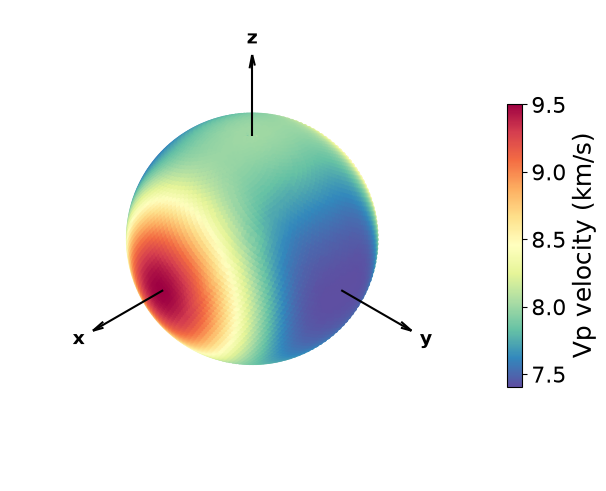

In [10]:
# plot to test
fig2, ax = plt.subplots(subplot_kw={"projection": "3d"}, constrained_layout=True)

speed = ax.scatter(x, y, z, c=velocities["Vp_phase_kms"], cmap="Spectral_r")

# add small x, y, z direction arrows originating from the sphere's surface
axis_length = 0.75
origins = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
directions = origins  # arrows point radially outward from the surface

ax.quiver(
    origins[:, 0], origins[:, 1], origins[:, 2],
    directions[:, 0], directions[:, 1], directions[:, 2],
    length=axis_length, color="black", linewidth=1.5, arrow_length_ratio=0.15,
    zorder=10,
)

label_offset = 1 + axis_length * 1.2
for axis_label, (lx, ly, lz) in zip("xyz", origins * label_offset):
    ax.text(lx, ly, lz, axis_label, fontsize=14, fontweight="bold", ha="center", va="center", zorder=10)

# add color bar
cbar = fig2.colorbar(speed, ax=ax, shrink=0.6, location="right")
cbar.set_label("Vp velocity (km/s)", fontsize=18)
cbar.ax.tick_params(labelsize=16)

# tweak plot
ax.axis("off")
ax.set_box_aspect([1, 1, 1])  # enforce equal aspect ratio
# isometric view so all three direction arrows are visible without foreshortening
ax.view_init(elev=np.degrees(np.arctan(1 / np.sqrt(2))), azim=45)


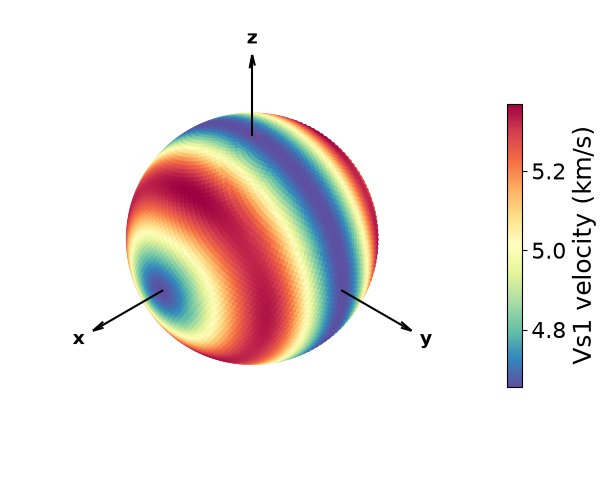

In [11]:
# plot to test
fig3, ax = plt.subplots(subplot_kw={"projection": "3d"}, constrained_layout=True)

speed = ax.scatter(x, y, z, c=velocities["Vs1_phase_kms"], cmap="Spectral_r")

# add small x, y, z direction arrows originating from the sphere's surface
axis_length = 0.75
origins = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
directions = origins  # arrows point radially outward from the surface

ax.quiver(
    origins[:, 0],
    origins[:, 1],
    origins[:, 2],
    directions[:, 0],
    directions[:, 1],
    directions[:, 2],
    length=axis_length,
    color="black",
    linewidth=1.5,
    arrow_length_ratio=0.15,
    zorder=10,
)

label_offset = 1 + axis_length * 1.2
for axis_label, (lx, ly, lz) in zip("xyz", origins * label_offset):
    ax.text(
        lx,
        ly,
        lz,
        axis_label,
        fontsize=14,
        fontweight="bold",
        ha="center",
        va="center",
        zorder=10,
    )

# add color bar
cbar = fig3.colorbar(speed, ax=ax, shrink=0.6, location="right")
cbar.set_label("Vs1 velocity (km/s)", fontsize=18)
cbar.ax.tick_params(labelsize=16)

# tweak plot
ax.axis("off")
ax.set_box_aspect([1, 1, 1])  # enforce equal aspect ratio
# isometric view so all three direction arrows are visible without foreshortening
ax.view_init(elev=np.degrees(np.arctan(1 / np.sqrt(2))), azim=45)

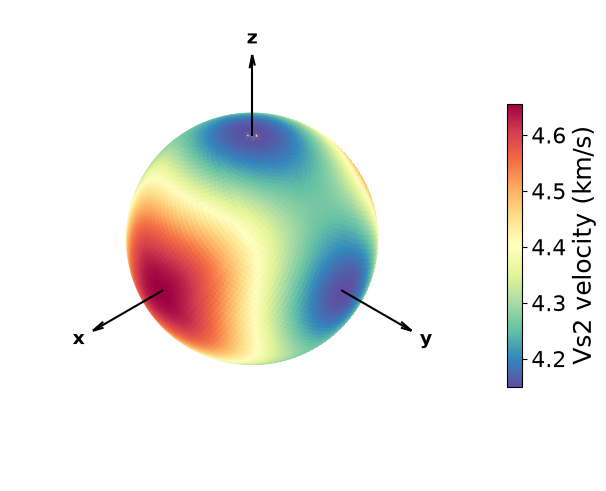

In [12]:
# plot to test
fig4, ax = plt.subplots(subplot_kw={"projection": "3d"}, constrained_layout=True)

speed = ax.scatter(x, y, z, c=velocities["Vs2_phase_kms"], cmap="Spectral_r")

# add small x, y, z direction arrows originating from the sphere's surface
axis_length = 0.75
origins = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
directions = origins  # arrows point radially outward from the surface

ax.quiver(
    origins[:, 0],
    origins[:, 1],
    origins[:, 2],
    directions[:, 0],
    directions[:, 1],
    directions[:, 2],
    length=axis_length,
    color="black",
    linewidth=1.5,
    arrow_length_ratio=0.15,
    zorder=10,
)

label_offset = 1 + axis_length * 1.2
for axis_label, (lx, ly, lz) in zip("xyz", origins * label_offset):
    ax.text(
        lx,
        ly,
        lz,
        axis_label,
        fontsize=14,
        fontweight="bold",
        ha="center",
        va="center",
        zorder=10,
    )

# add color bar
cbar = fig4.colorbar(speed, ax=ax, shrink=0.6, location="right")
cbar.set_label("Vs2 velocity (km/s)", fontsize=18)
cbar.ax.tick_params(labelsize=16)

# tweak plot
ax.axis("off")
ax.set_box_aspect([1, 1, 1])  # enforce equal aspect ratio
# isometric view so all three direction arrows are visible without foreshortening
ax.view_init(elev=np.degrees(np.arctan(1 / np.sqrt(2))), azim=45)


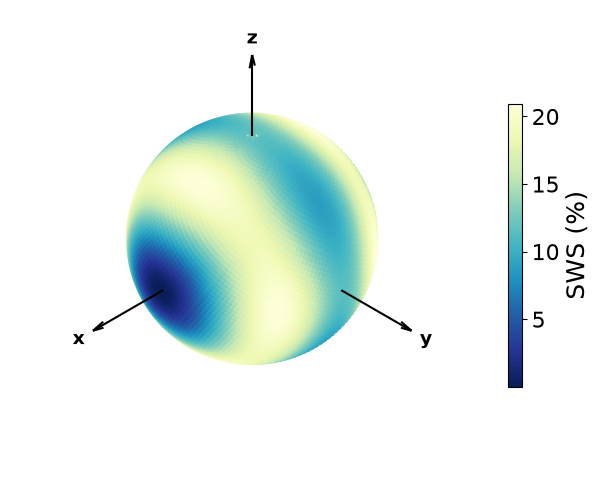

In [13]:
# plot to test
fig5, ax = plt.subplots(subplot_kw={"projection": "3d"}, constrained_layout=True)

speed = ax.scatter(x, y, z, c=velocities["SWS_perc"], cmap="YlGnBu_r")

# add small x, y, z direction arrows originating from the sphere's surface
axis_length = 0.75
origins = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
directions = origins  # arrows point radially outward from the surface

ax.quiver(
    origins[:, 0],
    origins[:, 1],
    origins[:, 2],
    directions[:, 0],
    directions[:, 1],
    directions[:, 2],
    length=axis_length,
    color="black",
    linewidth=1.5,
    arrow_length_ratio=0.15,
    zorder=10,
)

label_offset = 1 + axis_length * 1.2
for axis_label, (lx, ly, lz) in zip("xyz", origins * label_offset):
    ax.text(
        lx,
        ly,
        lz,
        axis_label,
        fontsize=14,
        fontweight="bold",
        ha="center",
        va="center",
        zorder=10,
    )

# add color bar
cbar = fig5.colorbar(speed, ax=ax, shrink=0.6, location="right")
cbar.set_label("SWS (%)", fontsize=18)
cbar.ax.tick_params(labelsize=16)

# tweak plot
ax.axis("off")
ax.set_box_aspect([1, 1, 1])  # enforce equal aspect ratio
# isometric view so all three direction arrows are visible without foreshortening
ax.view_init(elev=np.degrees(np.arctan(1 / np.sqrt(2))), azim=45)
